In [72]:
# All imports needed for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

pd.options.display.max_columns = 100

In [73]:
# Quick environment check
%cd /home/jovyan/work
!ls

/home/jovyan/work
decision_tree_submission.csv   README.md	      train.csv
FinalProject.ipynb	       sample_submission.csv  train_trimmed.csv
HuiDis_Data_Exploration.ipynb  test.csv
random_forest_submission.csv   train_clean.csv


In [74]:
# Load dataset and look at its shape and first 5 rows
dataset_path = 'train.csv'

train = pd.read_csv(dataset_path, low_memory=False)
print("Training Data:")
print(train.shape)
print(train.dtypes)
train.head(5)

Training Data:
(307178, 55)
INDEX_NR                  int64
INCIDENT_DATE            object
INCIDENT_MONTH            int64
INCIDENT_YEAR             int64
TIME                     object
TIME_OF_DAY              object
AIRPORT_ID               object
AIRPORT                  object
LATITUDE                 object
LONGITUDE                object
RUNWAY                   object
STATE                    object
FAAREGION                object
LOCATION                 object
OPID                     object
OPERATOR                 object
REG                      object
FLT                      object
AIRCRAFT                 object
AMA                      object
AMO                      object
EMA                     float64
EMO                     float64
AC_CLASS                 object
AC_MASS                 float64
TYPE_ENG                 object
NUM_ENGS                float64
ENG_1_POS               float64
ENG_2_POS               float64
ENG_3_POS               float64
ENG_4_POS   

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,SKY,PRECIPITATION,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,7,PR,ASO,NaN,AAL,AMERICAN AIRLINES,N892AA,NaN,B-727-200,148,11,34.0,10.0,A,4.0,D,3.0,5.0,6.0,5.0,NaN,Approach,300.0,145.0,NaN,Some Cloud,NaN,NaN,UNKBS,Unknown bird - small,0,NO SIGN OF BIRD ON A/C.,1,0,No,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,32R,FN,FGN,NaN,FDX,FEDEX EXPRESS,N608FE,5293,MD-11,583,39,22.0,7.0,A,4.0,D,3.0,1.0,6.0,1.0,NaN,Approach,50.0,NaN,0.0,NaN,NaN,NaN,UNKBM,Unknown bird - medium,0,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,0,0,Unknown,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,35L,KY,ASO,NaN,UPS,UPS AIRLINES,N141UP,907,A-300,04A,1,34.0,46.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Approach,3500.0,240.0,8.0,NaN,NaN,NaN,UNKBL,Unknown bird - large,0,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",0,0,No,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,25R,CA,AWP,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NE120,Western gull,0,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,1,0,Unknown,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,35,HI,AWP,NaN,1AAH,ALOHA AIRLINES,NaN,NaN,B-737-200,148,13,34.0,10.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Landing Roll,0.0,135.0,0.0,Some Cloud,NaN,NaN,R1101,American barn owl,0,TIME 0824 LCL.,0,0,No,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


In [75]:
def target_class_balance(axes, row, col):
    ax = axes[row, col]
    train["INDICATED_DAMAGE"].value_counts().plot.bar(
        ax=ax, color=["steelblue", "tomato"], edgecolor="white"
    )
    ax.set_title("Target Class Balance")
    ax.set_xlabel("Indicated Damage")
    ax.set_ylabel("Count")
    ax.set_xticklabels(["No Damage", "Damage"], rotation=0)

In [76]:
def strikes_by_month(axes, row, col):
    ax = axes[row, col]
    train.groupby("INCIDENT_MONTH")["INDICATED_DAMAGE"].agg(["count", "mean"]).pipe(
        lambda g: g["count"].plot.bar(ax=ax, color="steelblue", edgecolor="white")
    )
    ax.set_title("Strikes by Month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Count")
    ax.set_xticklabels(range(1, 13), rotation=0)

In [77]:
def damage_rate_by_bird_size(axes, row, col):
    ax = axes[row, col]
    if "SIZE" in train.columns:
        size_order = ["Small", "Medium", "Large"]
        dr = train.groupby("SIZE")["INDICATED_DAMAGE"].mean().reindex(size_order) * 100
        dr.plot.bar(ax=ax, color=["steelblue", "orange", "tomato"], edgecolor="white")
        ax.set_title("Damage Rate by Bird Size")
        ax.set_ylabel("Damage Rate (%)")
        ax.set_xlabel("Size")
        ax.tick_params(axis="x", rotation=0)

In [78]:
def damage_rate_by_phase_of_flight(axes, row, col):
    ax = axes[row, col]
    if "PHASE_OF_FLIGHT" in train.columns:
        phase_dr = (
            train.groupby("PHASE_OF_FLIGHT")["INDICATED_DAMAGE"]
            .mean()
            .sort_values(ascending=True) * 100
        )
        phase_dr.plot.barh(ax=ax, color="steelblue", edgecolor="white")
        ax.set_title("Damage Rate by Flight Phase")
        ax.set_xlabel("Damage Rate (%)")

In [79]:
def speed_distribution_by_damage(axes, row, col):
    ax = axes[row, col]
    if "SPEED" in train.columns:
        for label, group, color in [
            ("No Damage", train[train["INDICATED_DAMAGE"] == 0]["SPEED"].dropna(), "steelblue"),
            ("Damage",    train[train["INDICATED_DAMAGE"] == 1]["SPEED"].dropna(), "tomato"),
        ]:
            ax.hist(group.clip(0, 400), bins=40, alpha=0.6, label=label, color=color)
        ax.set_title("Speed Distribution by Damage")
        ax.set_xlabel("Airspeed (knots)")
        ax.set_ylabel("Count")
        ax.legend()

In [80]:
_missing = (train.isnull().mean() * 100).sort_values(ascending=False)
print(_missing)

def missing_values_by_cat(axes, row, col):
    ax = axes[row, col]
    missing = _missing.head(15)
    missing.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Top 15 Columns by Missing %")
    ax.set_xlabel("Missing (%)")

BIRD_BAND_NUMBER        99.767887
ENG_4_POS               98.935796
ENROUTE_STATE           98.259641
PRECIPITATION           96.349999
ENG_3_POS               95.977577
LOCATION                87.232810
SPEED                   69.040101
NUM_SEEN                67.890930
SKY                     53.006726
FLT                     52.554219
HEIGHT                  50.197931
TIME_OF_DAY             43.613475
PHASE_OF_FLIGHT         39.378146
REG                     38.733894
AMO                     38.027788
EMO                     36.843784
TIME                    35.566349
DISTANCE                33.629687
COMMENTS                33.558067
ENG_2_POS               33.371205
EMA                     33.342557
AMA                     28.939572
TYPE_ENG                28.578218
ENG_1_POS               28.555756
NUM_ENGS                28.549245
AC_MASS                 28.467533
AC_CLASS                28.424887
RUNWAY                  24.606254
LONGITUDE               13.264947
FAAREGION     

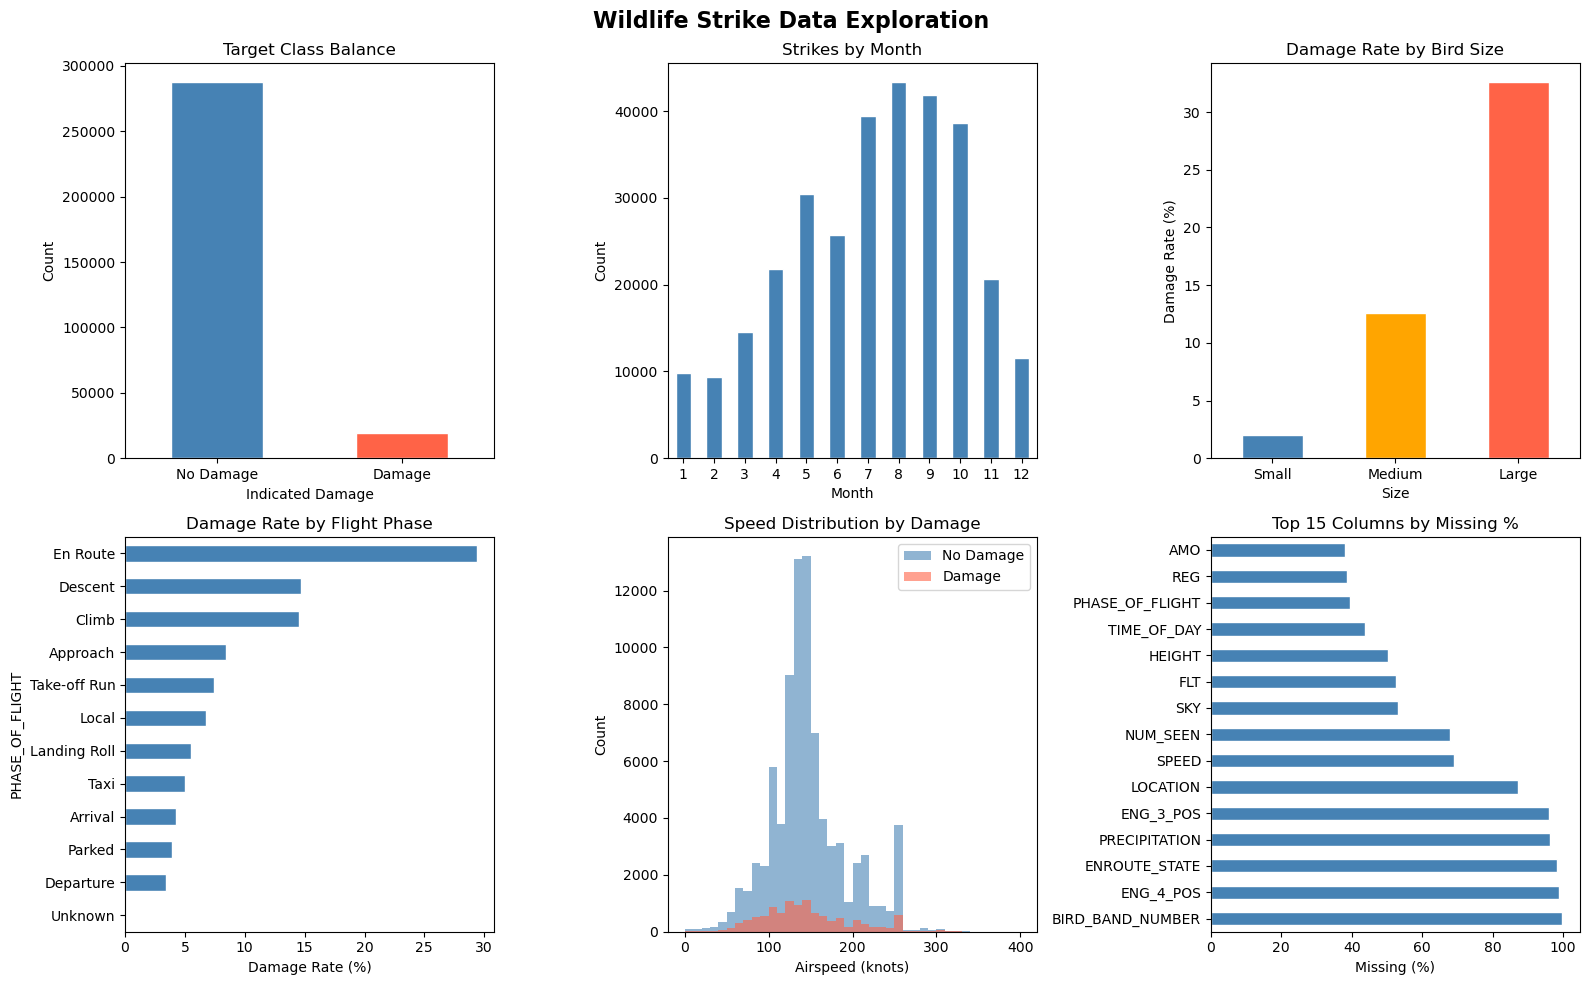

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Wildlife Strike Data Exploration ", fontsize=16, fontweight="bold")

target_class_balance(axes, 0, 0)
strikes_by_month(axes, 0, 1)
damage_rate_by_bird_size(axes, 0, 2)
damage_rate_by_phase_of_flight(axes, 1, 0)
speed_distribution_by_damage(axes, 1, 1)
missing_values_by_cat(axes, 1, 2)

plt.tight_layout()
plt.show()

In [100]:
struck_map = {
    "1": 1, "2": 2, "3": 3, "4": 4, "5": 5,
    "6": 6, "7": 7, "8": 8, "9": 9,
    "10-Feb": 6,       # 2 - 10 struck: midpoint = 6
    "11-100": 55,      # 11-100 struck: midpoint = 55
    "Over 100": 150,   # arbritrary count for over 100
}

# feature engineering
def _engineer_features(df):
    out = df.copy()
 
    # encoded num_struck -> numeric midpoints
    if "NUM_STRUCK" in out.columns:
        out["NUM_STRUCK"] = out["NUM_STRUCK"].astype('string').map(struck_map)
 
    # migration season flag (Mar–May, Aug–Nov)
    if "INCIDENT_MONTH" in out.columns:
        out["IS_MIGRATION_SEASON"] = out["INCIDENT_MONTH"].isin(
            [3, 4, 5, 8, 9, 10, 11]
        ).astype(int)
 
    # low-visibility time flag
    if "TIME_OF_DAY" in out.columns:
        out["IS_LOW_VISIBILITY_TIME"] = out["TIME_OF_DAY"].isin(
            ["Dawn", "Dusk", "Night"]
        ).astype(int)
 
    # log-scale height + missingness flag
    if "HEIGHT" in out.columns:
        out["HEIGHT"] = np.log1p(out["HEIGHT"].clip(lower=0))
        out["HEIGHT_MISSING"] = out["HEIGHT"].isna().astype(int)
 
 
    return out

In [101]:
selected_columns = [
    # original features
    "LATITUDE",
    "LONGITUDE",
    "AC_CLASS",
    "AC_MASS",
    "TYPE_ENG",
    "NUM_ENGS",
    "PHASE_OF_FLIGHT",
    "HEIGHT",           # modified to log scale 
    # "SPEED",
    "INCIDENT_MONTH",
    "TIME_OF_DAY",
    "SPECIES_ID",
    "SIZE",
    "NUM_STRUCK",       # decoded to numerical
    "WARNED",
    "INDICATED_DAMAGE",

    # synthesized features
    "IS_MIGRATION_SEASON",
    "IS_LOW_VISIBILITY_TIME",
    "HEIGHT_MISSING",
]
 
numeric_features = [
    # original features
    "LATITUDE", 
    "LONGITUDE", 
    "AC_MASS", 
    "NUM_ENGS",
    "HEIGHT", # 
    # "SPEED", 
    "INCIDENT_MONTH",
    "NUM_STRUCK",
    
    # synthesized features
    "IS_MIGRATION_SEASON",
    "IS_LOW_VISIBILITY_TIME",
    "HEIGHT_MISSING",
]

categorical_features = [
    "AC_CLASS", 
    "TYPE_ENG", 
    "PHASE_OF_FLIGHT",
    "TIME_OF_DAY", 
    "SPECIES_ID", 
    "SIZE",
    "WARNED"
]

feature_columns = [c for c in selected_columns if c != "INDICATED_DAMAGE"]

In [109]:
def clean_feature_frame(df, columns):
    # Copy only the columns we need so later cleaning does not affect the original dataframe.
    cleaned = df.filter(items=columns).copy()

    # Convert numeric columns to numbers. Any invalid value becomes NaN.
    for col in numeric_features:
        if col in cleaned.columns:
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")
    
    # Treat blank categorical values as missing so the imputer can handle them consistently.
    for col in categorical_features:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].replace(r"^\s*$", np.nan, regex=True)

    return cleaned


def prepare_training_data(df):
    # Clean the training columns first so missing and malformed values are standardized.
    cleaned = clean_feature_frame(df, selected_columns)

    # Drop rows only when the target is missing. Feature NaNs will be handled in the model pipeline.
    cleaned = cleaned.dropna(subset=["INDICATED_DAMAGE"]).copy()
    return cleaned


def prepare_prediction_data(df):
    # Clean the test features but keep rows with missing feature values for the imputer to fill.
    return clean_feature_frame(df, feature_columns)


print("Preparing training data...")
train_clean = prepare_training_data(_engineer_features(train))
print("Training data prepared.")

Preparing training data...
Training data prepared.


In [112]:
# Take a quick look at the cleaned training data.
print("Cleaned Training Data:")
print(train_clean.shape)
print(train_clean.dtypes)
train_clean.head(10)

Cleaned Training Data:
(307178, 18)
LATITUDE                  float64
LONGITUDE                 float64
AC_CLASS                   object
AC_MASS                   float64
TYPE_ENG                   object
NUM_ENGS                  float64
PHASE_OF_FLIGHT            object
HEIGHT                    float64
INCIDENT_MONTH              int64
TIME_OF_DAY                object
SPECIES_ID                 object
SIZE                       object
NUM_STRUCK                float64
WARNED                     object
INDICATED_DAMAGE            int64
IS_MIGRATION_SEASON         int64
IS_LOW_VISIBILITY_TIME      int64
HEIGHT_MISSING              int64
dtype: object


,LATITUDE,LONGITUDE,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,PHASE_OF_FLIGHT,HEIGHT,INCIDENT_MONTH,TIME_OF_DAY,SPECIES_ID,SIZE,NUM_STRUCK,WARNED,INDICATED_DAMAGE,IS_MIGRATION_SEASON,IS_LOW_VISIBILITY_TIME,HEIGHT_MISSING
0,18.439420,-66.001830,A,4.0,D,3.0,Approach,5.707110,12,Day,UNKBS,Small,6.0,No,0,0,0,0
1,2.745578,101.709917,A,4.0,D,3.0,Approach,3.931826,2,Night,UNKBM,Medium,1.0,Unknown,0,0,1,0
2,38.174390,-85.736000,A,4.0,D,2.0,Approach,8.160804,5,Night,UNKBL,Large,1.0,No,1,1,1,0
3,33.942540,-118.408070,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NE120,Medium,6.0,Unknown,0,1,0,1
4,21.975980,-159.338960,A,4.0,D,2.0,Landing Roll,0.000000,2,Dawn,R1101,Medium,1.0,No,0,0,1,0
5,25.077731,121.232822,A,4.0,D,2.0,Landing Roll,0.000000,7,Day,UNKBS,Small,1.0,Unknown,0,0,0,0
6,29.993390,-90.258030,A,4.0,D,2.0,Take-off Run,0.000000,6,Day,UNKBS,Small,1.0,Yes,0,0,0,0
7,41.708950,-86.318470,A,3.0,D,2.0,Take-off Run,0.000000,8,Day,O2205,Small,6.0,No,0,1,0,0
8,40.639750,-73.778930,A,4.0,D,2.0,Take-off Run,0.000000,9,NaN,K2001,Large,1.0,Unknown,0,1,0,0
9,40.692500,-74.168660,A,4.0,D,2.0,Landing Roll,0.000000,10,Night,R2203,Large,1.0,Unknown,0,1,1,0


In [ ]:
# save cleaned data to csv
train_clean.to_csv('train_HuiDi_1.csv', index=False)